In [35]:
import kagglehub
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import image as mpimg
import numpy as np
from NeuralNetwork import NeuralNetwork, Dense, Tanh, ReLU, Softmax
import os
from PIL import Image

# Loading Data

In [8]:
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

Resuming download from 404750336 bytes (421229242 bytes left)...
Resuming download to /Users/vishvarao/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/1.archive (404750336/825979578) bytes left.


100%|██████████████████████████████████████████████| 788M/788M [00:06<00:00, 60.4MB/s]

Extracting files...


In [11]:
print("Path to dataset files:", path)

Path to dataset files: /Users/vishvarao/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1


In [41]:
dog_path = os.path.join(path, 'PetImages', 'Dog')
cat_path = os.path.join(path, 'PetImages', 'Cat')
dog_path, cat_path

('/Users/vishvarao/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Dog',
 '/Users/vishvarao/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Cat')

In [42]:
dog_images = os.listdir(dog_path)
cat_images = os.listdir(cat_path)

In [43]:
len(dog_images), len(cat_images)

(12501, 12501)

In [44]:
dog_images[0]

'9733.jpg'

In [45]:
def display_image(path, file_name):
    image_path = os.path.join(path, file_name)
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.show()

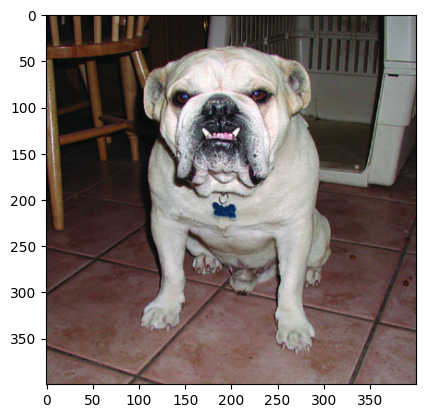

In [74]:
display_image(dog_path, dog_images[2388])

# Processing Images

In [106]:
def process_images(length, width, path, images):
    data = []
    for index, img in enumerate(images):
        if img.split('.')[1] != "jpg": continue
        try:
            with Image.open(os.path.join(path, img)) as i:
                i = i.convert("RGB")
                i = i.resize((length, width))
                data.append(np.array(i))
        except: print(f"Could not find image: {os.path.join(path, img)}")
    return np.mean(np.array(data), axis=3) / 255

In [107]:
dogs = process_images(100, 100, dog_path, dog_images)
cats = process_images(100, 100, cat_path, cat_images)

Could not find image: /Users/vishvarao/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Dog/11702.jpg
Could not find image: /Users/vishvarao/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Cat/666.jpg


In [109]:
dogs.shape, cats.shape

((12499, 100, 100), (12499, 100, 100))

In [120]:
data = np.concatenate((dogs, cats))
label_dogs = np.ones((dogs.shape[0], 1))
label_cats = np.zeros((cats.shape[0], 1))
labels = np.concatenate((label_dogs, label_cats))
data.shape, labels.shape

((24998, 100, 100), (24998, 1))

In [123]:
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

In [124]:
data, labels = unison_shuffled_copies(data, labels)

In [182]:
def display_matrix(data, labels, index):
    if data[index].shape[-1] != 3: plt.imshow(data[index], cmap='gray')
    else: plt.imshow(data[index])
    print(f"Label: {labels[index]}")
    plt.show()

Label: [1.]


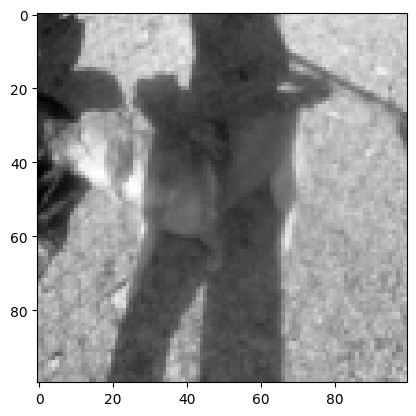

In [183]:
display_matrix(data, labels, 10)

In [144]:
def train_test_split(X, y, pct):
    length = len(X)
    assert length == len(y)
    train_length = int(length * (1 - pct))
    return X[:train_length], y[:train_length], X[train_length:], y[train_length:]

In [145]:
X_train, y_train, X_test, y_test = train_test_split(data, labels, 0.2)

In [170]:
def one_hot_encode(labels):
    l = []
    for label in labels:
        if label == 0: l.append([1, 0])
        else: l.append([0, 1])
    return np.array(l).reshape(-1, 2, 1)

In [171]:
y_train_hot = one_hot_encode(y_train)
X_train = X_train.reshape(X_train.shape[0], -1, 1)
X_train.shape, y_train_hot.shape

((19998, 10000, 1), (19998, 2, 1))

# Training Model

In [172]:
NN = NeuralNetwork((
    Dense(10000, 64),
    ReLU(),
    Dense(64, 32),
    ReLU(),
    Dense(32, 16),
    ReLU(),
    Dense(16, 2),
    Softmax()
))

In [173]:
NN.train(X_train, y_train_hot, learning_rate=0.001, epoch=16, batch_size=100)

Epoch: 1/16 | Cross Entropy Loss: 0.7177922530865334 | Accuracy: 0.5402540254025403
Epoch: 2/16 | Cross Entropy Loss: 0.6877314187122928 | Accuracy: 0.5668066806680668
Epoch: 3/16 | Cross Entropy Loss: 0.673569473489343 | Accuracy: 0.5904090409040904
Epoch: 4/16 | Cross Entropy Loss: 0.6708560054163111 | Accuracy: 0.59000900090009
Epoch: 5/16 | Cross Entropy Loss: 0.6666242583805404 | Accuracy: 0.5939093909390939
Epoch: 6/16 | Cross Entropy Loss: 0.6624126429188617 | Accuracy: 0.6011101110111011
Epoch: 7/16 | Cross Entropy Loss: 0.6601322802971028 | Accuracy: 0.5975097509750975
Epoch: 8/16 | Cross Entropy Loss: 0.6595564173028732 | Accuracy: 0.6018601860186018
Epoch: 9/16 | Cross Entropy Loss: 0.65368667770523 | Accuracy: 0.611911191119112
Epoch: 10/16 | Cross Entropy Loss: 0.6542846955882862 | Accuracy: 0.6100610061006101
Epoch: 11/16 | Cross Entropy Loss: 0.6557526314446821 | Accuracy: 0.6086108610861086
Epoch: 12/16 | Cross Entropy Loss: 0.6507426203198903 | Accuracy: 0.615461546154